In [3]:
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.append("../utils/py")
import miniramses as ram

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 180
plt.rcParams.update({
    "font.size": 14,
    "legend.fontsize": 16,
})


import sys

# Try both repo-root and analyze/ working directories.
for cand in [Path("utils/py"), Path("../utils/py")]:
    if cand.exists() and str(cand.resolve()) not in sys.path:
        sys.path.append(str(cand.resolve()))

import miniramses as ram

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11

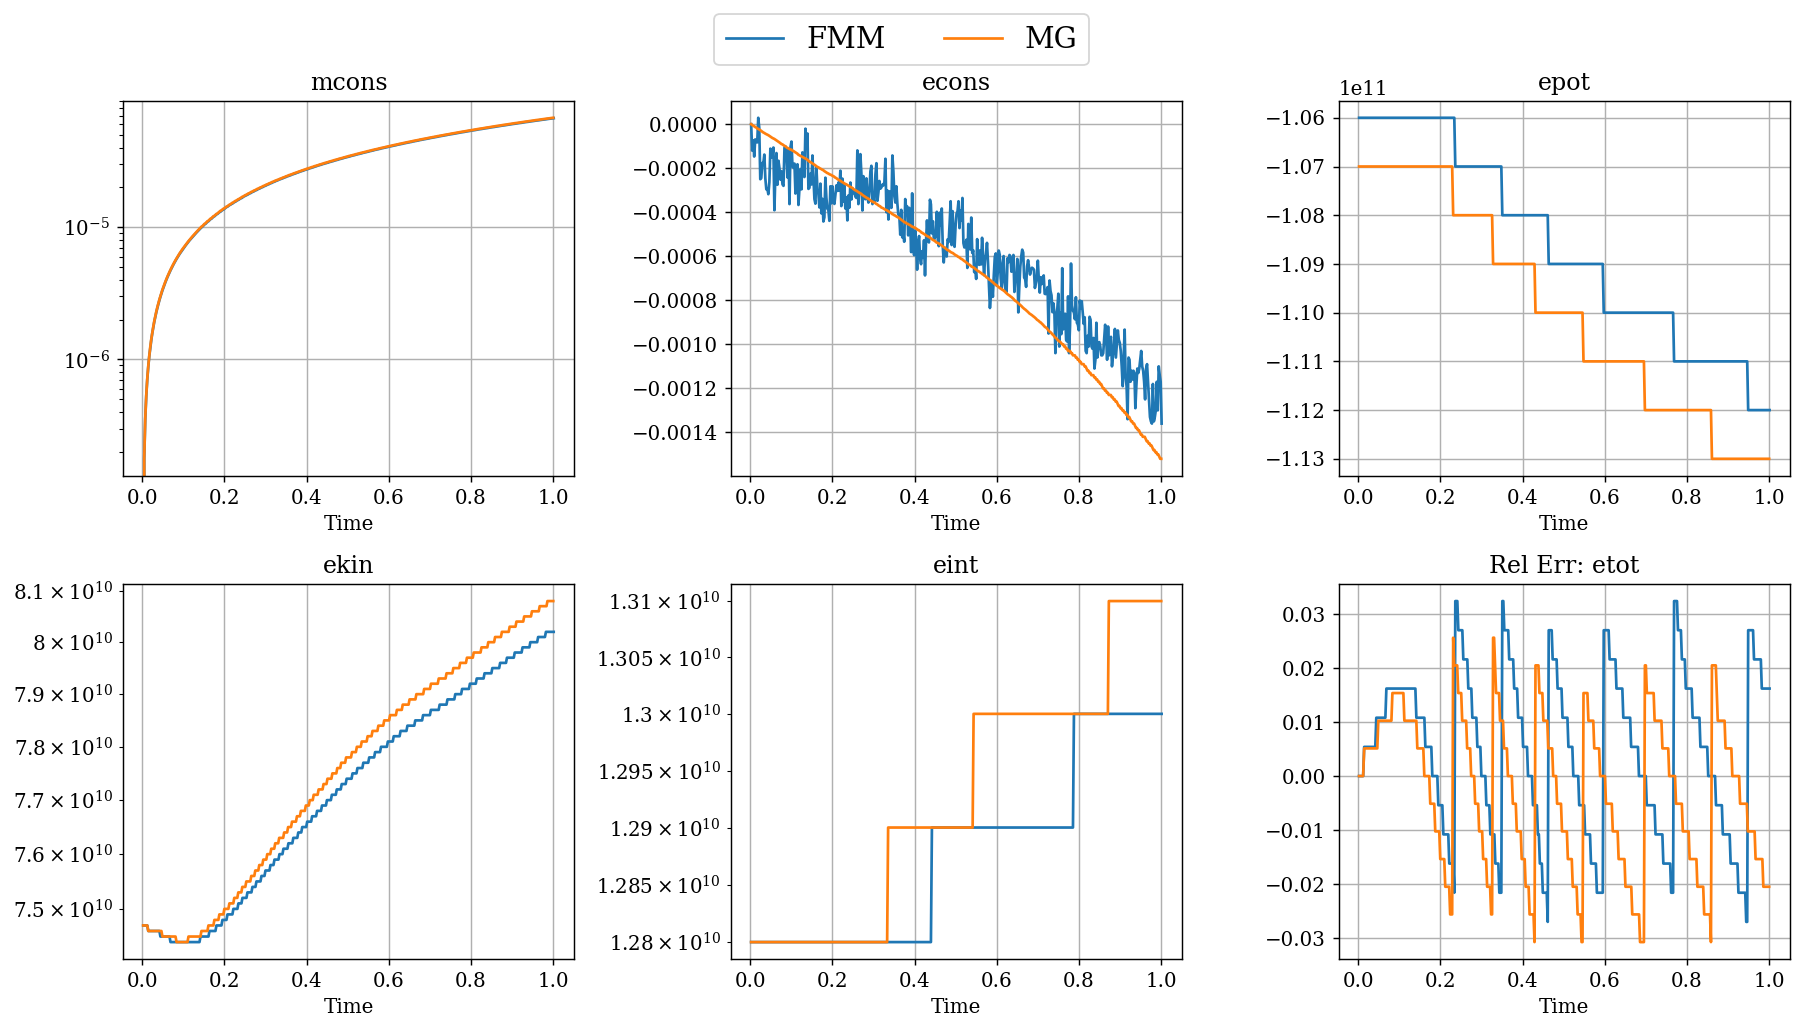

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(filename):
    main_pattern = re.compile(
        r"Main step=\s*(\d+)\s+"
        r"mcons=\s*([-\d.E+]+)\s+"
        r"econs=\s*([-\d.E+]+)\s+"
        r"epot=\s*([-\d.E+]+)\s+"
        r"ekin=\s*([-\d.E+]+)\s+"
        r"eint=\s*([-\d.E+]+)"
    )

    time_pattern = re.compile(
        r"Fine step=\s*\d+\s+t=\s*([-\d.E+]+)"
    )

    data = []
    current_time = None

    with open(filename, "r") as f:
        for line in f:
            # update time whenever we see it
            t_match = time_pattern.search(line)
            if t_match:
                current_time = float(t_match.group(1))

            # parse main step
            m = main_pattern.search(line)
            if m:
                step, mcons, econs, epot, ekin, eint = m.groups()
                data.append({
                    "step": int(step),
                    "time": float(current_time),  # <-- attach time here
                    "mcons": float(mcons),
                    "econs": float(econs),
                    "epot": float(epot),
                    "ekin": float(ekin),
                    "eint": float(eint),
                    "etot": float(epot) + float(ekin) + float(eint),
                })

    return pd.DataFrame(data).sort_values("step").reset_index(drop=True)


df_fmm = parse_file("/home/jl4415/mini-ramses/halo_test/halo_fmm/fmm_2707491.out")
df_mg  = parse_file("/home/jl4415/mini-ramses/halo_test/halo_mg/mg_2707491.out")


vars_list = ["mcons", "econs", "epot", "ekin", "eint", "etot"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(vars_list):
    ax = axes[i]

    if var == "etot":
        ax.plot(df_fmm["time"], (df_fmm[var]-df_fmm[var].iloc[0])/df_fmm[var].iloc[0], label="FMM")
        ax.plot(df_mg["time"], (df_mg[var]-df_mg[var].iloc[0])/df_mg[var].iloc[0], label="MG")
    else:
        ax.plot(df_fmm["time"], df_fmm[var], label="FMM")
        ax.plot(df_mg["time"], df_mg[var], label="MG")

    if var == "etot":
        ax.set_title("Rel Err: etot")
    else:
        ax.set_title(var)
        
    ax.set_xlabel("Time")
    ax.grid(True)

    # 🔑 smart scaling
    if var in ["mcons"]:
        ax.set_yscale("log")
    else:
        if (df_fmm[var] > 0).all() and (df_mg[var] > 0).all():
            ax.set_yscale("log")


# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('./fig/isolated_halo_diag.png')
plt.show()

In [9]:
# -----------------------------
# User configuration
# -----------------------------
RUNS = {
    "MG": "/home/jl4415/mini-ramses/halo_test/halo_mg",
    "FMM": "/home/jl4415/mini-ramses/halo_test/halo_fmm",
}

# Optional output filtering
NOUT_MIN: Optional[int] = None
NOUT_MAX: Optional[int] = None
MAX_OUTPUTS_PER_RUN: Optional[int] = None

# Spatial subset for faster analysis (None = full domain)
CENTER: Optional[Tuple[float, float, float]] = (300.0, 300.0, 300.0)
RADIUS: Optional[float] = None

# Coordinate/frame alignment options
# Some halo outputs store AMR cells in [300, 900] while particles are in [0, 600].
# We auto-align coordinates to CENTER using shifts in ALIGN_SHIFT_TRIALS * inferred_boxlen.
PHYSICAL_BOXLEN: Optional[float] = None  # None => infer from info.boxlen and CENTER
AUTO_ALIGN_COORDS = True
ALIGN_SHIFT_TRIALS = [0.0, -0.5, 0.5, -1.0, 1.0]
PRINT_ALIGNMENT_DEBUG = True

# Conservation options
INCLUDE_PARTICLES = False
INCLUDE_PARTICLES_IF_NO_HYDRO = True

# Time matching tolerance between two runs (None = nearest without limit)
TIME_MATCH_TOLERANCE: Optional[float] = None

# Radial profile settings
N_RADIAL_BINS = 96
RADIAL_RMAX: Optional[float] = None
PROFILE_SNAPSHOT = "last"  # "first", "last", or int nout from run A
PROFILE_FIELDS = ["density", "pressure", "temperature", "potential", "speed"]

# Optional (expensive) profile mismatch over time
COMPUTE_PROFILE_MISMATCH_OVER_TIME = False
PROFILE_MISMATCH_FIELD = "density"

# Uniform slice comparison settings
MAP_FIELD = "density"  # fallback to potential if unavailable
SLICE_Z = 300.0
SLICE_THICKNESS = 6.0
SLICE_NXY = 512
SLICE_BOX = [225.0, 375.0, 225.0, 375.0]  # [xmin, xmax, ymin, ymax] or None

# Save outputs
SAVE_RESULTS = True
RESULTS_DIR = Path("./isolated_halo_stability_results")


In [12]:
# -----------------------------
# Helpers
# -----------------------------

def discover_outputs(run_dir: str) -> pd.DataFrame:
    run = Path(run_dir)
    rows = []
    for d in sorted(run.glob("output_*")):
        if not d.is_dir():
            continue
        m = re.fullmatch(r"output_(\d+)", d.name)
        if not m:
            continue
        nout = int(m.group(1))
        try:
            info = ram.rd_info(nout, path=str(run))
        except Exception:
            continue
        rows.append(
            {
                "nout": nout,
                "output_dir": str(d),
                "time": float(info.time),
                "aexp": float(info.aexp),
                "gamma": float(info.gamma),
                "boxlen": float(info.boxlen),
                "ndim": int(info.ndim),
            }
        )

    if not rows:
        return pd.DataFrame(columns=["nout", "output_dir", "time", "aexp", "gamma", "boxlen", "ndim"])

    out = pd.DataFrame(rows).sort_values("nout").reset_index(drop=True)
    if NOUT_MIN is not None:
        out = out[out["nout"] >= NOUT_MIN]
    if NOUT_MAX is not None:
        out = out[out["nout"] <= NOUT_MAX]
    out = out.reset_index(drop=True)
    if MAX_OUTPUTS_PER_RUN is not None and len(out) > MAX_OUTPUTS_PER_RUN:
        out = out.iloc[:MAX_OUTPUTS_PER_RUN].copy()
    return out


def parse_header_vars(output_dir: str, prefix: str = "hydro") -> List[str]:
    p = Path(output_dir) / f"{prefix}_header.txt"
    if not p.exists():
        return []
    names = []
    for line in p.read_text().splitlines():
        m = re.search(r"variable\s*#\s*\d+\s*:\s*(.+)$", line.strip(), re.IGNORECASE)
        if m:
            names.append(m.group(1).strip().lower())
    return names


def has_file_for_output(run_dir: str, nout: int, stem: str) -> bool:
    out = Path(run_dir) / f"output_{nout:05d}"
    return (out / f"{stem}.00001").exists()


def classify_hydro_vars(header_names: List[str], ndim: int, nvar: int) -> Dict[str, Optional[List[int]]]:
    cls = {
        "density": 0,
        "velocity": list(range(1, min(1 + ndim, nvar))),
        "momentum": [],
        "pressure": None,
        "total_energy": None,
    }
    if not header_names:
        return cls

    cls["velocity"] = []
    for idx, name in enumerate(header_names[:nvar]):
        n = name.lower()
        if "density" in n:
            cls["density"] = idx
        if any(tok in n for tok in ["velocity", "vel_x", "vel_y", "vel_z", "vx", "vy", "vz"]):
            cls["velocity"].append(idx)
        if any(tok in n for tok in ["momentum", "mom_x", "mom_y", "mom_z", "rho_u", "rho_v", "rho_w"]):
            cls["momentum"].append(idx)
        if any(tok in n for tok in ["thermal_pressure", "pressure"]) and "total" not in n:
            cls["pressure"] = idx
        if any(tok in n for tok in ["total_energy", "energy"]) and "internal" not in n and "kinetic" not in n:
            cls["total_energy"] = idx

    cls["velocity"] = sorted([i for i in cls["velocity"] if i < nvar])[:ndim]
    cls["momentum"] = sorted([i for i in cls["momentum"] if i < nvar])[:ndim]
    return cls


def infer_center(info, center_cfg: Optional[Tuple[float, float, float]]) -> np.ndarray:
    if center_cfg is not None:
        return np.array(center_cfg, dtype=float)
    return np.full(info.ndim, info.boxlen / 2.0, dtype=float)


def infer_physical_boxlen(info, center_cfg: Optional[Tuple[float, float, float]]) -> float:
    if PHYSICAL_BOXLEN is not None:
        return float(PHYSICAL_BOXLEN)

    raw = float(info.boxlen)
    if center_cfg is None:
        return raw

    c = np.array(center_cfg, dtype=float)[: info.ndim]
    c = c[np.isfinite(c) & (c > 0)]
    if c.size == 0:
        return raw

    guess = 2.0 * float(np.median(c))
    if 0.0 < guess < 0.95 * raw:
        return guess
    return raw


def align_positions_to_center(pos: np.ndarray, center: np.ndarray, boxlen_phys: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(pos[: len(center)], dtype=np.float64).copy()
    shifts = np.zeros(len(center), dtype=np.float64)

    trials = [0.0]
    if AUTO_ALIGN_COORDS:
        trials = [float(t) * boxlen_phys for t in ALIGN_SHIFT_TRIALS]

    for d in range(len(center)):
        med = float(np.nanmedian(x[d]))
        best_shift = trials[0]
        best_err = abs((med + best_shift) - center[d])
        for s in trials[1:]:
            err = abs((med + s) - center[d])
            if err < best_err:
                best_err = err
                best_shift = s
        x[d] += best_shift
        shifts[d] = best_shift

    return x, shifts


def get_aligned_cell_positions(c, info, center_cfg: Optional[Tuple[float, float, float]]):
    center = infer_center(info, center_cfg)[: c.ndim]
    boxlen_phys = infer_physical_boxlen(info, center_cfg)
    x_aligned, shifts = align_positions_to_center(c.x, center, boxlen_phys)
    return x_aligned, shifts, center, boxlen_phys


def format_alignment(label: str, x_raw: np.ndarray, x_aligned: np.ndarray, shifts: np.ndarray) -> str:
    axes = "xyzuvw"
    parts = []
    for d in range(x_aligned.shape[0]):
        parts.append(
            f"{axes[d]} raw[{np.min(x_raw[d]):.3f},{np.max(x_raw[d]):.3f}]"
            f" -> aligned[{np.min(x_aligned[d]):.3f},{np.max(x_aligned[d]):.3f}]"
            f" shift={shifts[d]:+.3f}"
        )
    return f"[{label}] " + "; ".join(parts)


def subset_array_by_mask(arr: Optional[np.ndarray], mask: np.ndarray) -> Optional[np.ndarray]:
    if arr is None:
        return None
    a = np.asarray(arr)
    if a.ndim == 1 and a.shape[0] == mask.shape[0]:
        return a[mask]
    return a


def apply_radial_mask(fields: Dict[str, Optional[np.ndarray]], rr: np.ndarray, radius: Optional[float]):
    if radius is None:
        return fields, np.ones(rr.shape[0], dtype=bool)
    mask = rr <= float(radius)
    out = {}
    for k, v in fields.items():
        out[k] = subset_array_by_mask(v, mask)
    return out, mask


def read_cells(run_dir: str, nout: int):
    kwargs = {"path": run_dir}

    hydro_ok = has_file_for_output(run_dir, nout, "hydro")
    if hydro_ok:
        c = ram.rd_cell(nout, **kwargs)
        mode = "hydro+grav"
    else:
        kwargs["prefix"] = "grav"
        c = ram.rd_cell(nout, **kwargs)
        mode = "grav-only"
    return c, mode


def extract_fields(c, info, hydro_header_names: List[str], mode: str) -> Dict[str, Optional[np.ndarray]]:
    vol = np.asarray(c.dx, dtype=np.float64) ** c.ndim
    out = {
        "vol": vol,
        "density": None,
        "pressure": None,
        "temperature": None,
        "speed": None,
        "potential": np.asarray(c.g[0], dtype=np.float64) if c.g.shape[0] >= 1 else None,
    }

    if mode != "hydro+grav":
        return out

    nvar = c.u.shape[0]
    ndim = c.ndim
    cls = classify_hydro_vars(hydro_header_names, ndim, nvar)

    rho = np.asarray(c.u[cls["density"]], dtype=np.float64)
    if cls["velocity"] and len(cls["velocity"]) == ndim:
        vel = np.vstack([c.u[i] for i in cls["velocity"]]).astype(np.float64)
    elif cls["momentum"] and len(cls["momentum"]) == ndim:
        mom = np.vstack([c.u[i] for i in cls["momentum"]]).astype(np.float64)
        vel = mom / np.maximum(rho, 1e-30)
    else:
        vel = np.zeros((ndim, c.ncell), dtype=np.float64)

    vsq = np.sum(vel**2, axis=0)

    pressure = None
    if cls["pressure"] is not None:
        pressure = np.asarray(c.u[cls["pressure"]], dtype=np.float64)
    elif cls["total_energy"] is not None:
        etot = np.asarray(c.u[cls["total_energy"]], dtype=np.float64)
        pressure = (info.gamma - 1.0) * (etot - 0.5 * rho * vsq)

    out["density"] = rho
    out["speed"] = np.sqrt(vsq)
    out["pressure"] = pressure
    if pressure is not None:
        out["temperature"] = (pressure / np.maximum(rho, 1e-30)) * info.unit_T2

    return out


def compute_snapshot_diagnostics(run_dir: str, nout: int) -> Dict[str, float]:
    info = ram.rd_info(nout, path=run_dir)
    c, mode = read_cells(run_dir, nout)

    hydro_names = parse_header_vars(Path(run_dir) / f"output_{nout:05d}", prefix="hydro")
    f = extract_fields(c, info, hydro_names, mode)

    x_aligned, shifts, center_vec, boxlen_phys = get_aligned_cell_positions(c, info, CENTER)
    rr = np.sqrt(np.sum((x_aligned.T - center_vec[: c.ndim]) ** 2, axis=1))
    f, mask = apply_radial_mask(f, rr, RADIUS)

    row = {
        "nout": int(nout),
        "time": float(info.time),
        "aexp": float(info.aexp),
        "gamma": float(info.gamma),
        "boxlen": float(info.boxlen),
        "boxlen_phys": float(boxlen_phys),
        "mode": mode,
        "ncell": int(np.count_nonzero(mask)),
        "dx_min": float(np.min(c.dx[mask])) if np.count_nonzero(mask) > 0 else np.nan,
        "dx_max": float(np.max(c.dx[mask])) if np.count_nonzero(mask) > 0 else np.nan,
        "coord_shift_x": float(shifts[0]) if len(shifts) > 0 else np.nan,
        "coord_shift_y": float(shifts[1]) if len(shifts) > 1 else np.nan,
        "coord_shift_z": float(shifts[2]) if len(shifts) > 2 else np.nan,
        "gas_mass": np.nan,
        "gas_kinetic": np.nan,
        "gas_thermal": np.nan,
        "gas_potential": np.nan,
        "gas_total": np.nan,
        "part_mass": np.nan,
        "part_kinetic": np.nan,
    }

    if f["density"] is not None:
        rho = f["density"]
        row["gas_mass"] = float(np.sum(rho * f["vol"]))

        if f["speed"] is not None:
            row["gas_kinetic"] = float(np.sum(0.5 * rho * (f["speed"] ** 2) * f["vol"]))

        if f["pressure"] is not None:
            row["gas_thermal"] = float(np.sum((f["pressure"] / (info.gamma - 1.0)) * f["vol"]))

        if f["potential"] is not None:
            row["gas_potential"] = float(0.5 * np.sum(rho * f["potential"] * f["vol"]))

        row["gas_total"] = float(np.nansum([row["gas_kinetic"], row["gas_thermal"], row["gas_potential"]]))

    should_read_parts = INCLUDE_PARTICLES or (INCLUDE_PARTICLES_IF_NO_HYDRO and mode != "hydro+grav")
    if should_read_parts and has_file_for_output(run_dir, nout, "part"):
        try:
            p = ram.rd_part(nout, path=run_dir, silent=True)
            row["part_mass"] = float(np.sum(p.mass))
            row["part_kinetic"] = float(0.5 * np.sum(p.mass * np.sum(p.vel**2, axis=0)))
        except Exception as e:
            print(f"[warn] failed to read particles for {run_dir} output_{nout:05d}: {e}")

    return row


def add_rel_drifts(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col not in out.columns:
            continue
        s = out[col].astype(float)
        if s.notna().sum() == 0:
            out[f"{col}_rel_drift"] = np.nan
            continue
        i0 = s.first_valid_index()
        v0 = s.loc[i0]
        denom = abs(v0) if np.isfinite(v0) and abs(v0) > 0 else 1.0
        out[f"{col}_rel_drift"] = (s - v0) / denom
    return out


def match_by_time(df_a: pd.DataFrame, df_b: pd.DataFrame, tol: Optional[float] = None) -> pd.DataFrame:
    a = df_a[["nout", "time"]].sort_values("time").rename(columns={"nout": "nout_a", "time": "time_a"})
    b = df_b[["nout", "time"]].sort_values("time").rename(columns={"nout": "nout_b", "time": "time_b"})

    merged = pd.merge_asof(
        a,
        b,
        left_on="time_a",
        right_on="time_b",
        direction="nearest",
        tolerance=tol,
    )
    merged = merged.dropna(subset=["nout_b"]).copy()
    merged["nout_b"] = merged["nout_b"].astype(int)
    merged["dt"] = merged["time_b"] - merged["time_a"]
    return merged


def radial_profile(x: np.ndarray, field: np.ndarray, center: np.ndarray, r_edges: np.ndarray, vol_w: np.ndarray) -> np.ndarray:
    rr = np.sqrt(np.sum((x.T - center[: x.shape[0]]) ** 2, axis=1))
    num = np.histogram(rr, bins=r_edges, weights=field * vol_w)[0]
    den = np.histogram(rr, bins=r_edges, weights=vol_w)[0]
    prof = np.full_like(num, np.nan, dtype=float)
    ok = den > 0
    prof[ok] = num[ok] / den[ok]
    return prof


def relative_profile_error(prof_a: np.ndarray, prof_b: np.ndarray, eps: float = 1e-30) -> float:
    m = np.isfinite(prof_a) & np.isfinite(prof_b)
    if not np.any(m):
        return np.nan
    return float(np.mean(np.abs(prof_b[m] - prof_a[m]) / (np.abs(prof_a[m]) + eps)))


def uniform_slice_binned(x: np.ndarray, dx: np.ndarray, ndim: int, field: np.ndarray, z0: float, thickness: float, nxy: int, box=None):
    x0, y0, z = x[0], x[1], x[2]
    mask = np.abs(z - z0) <= 0.5 * (thickness + dx)

    if np.count_nonzero(mask) == 0:
        raise ValueError("No cells intersect selected slice.")

    x_m = x0[mask]
    y_m = y0[mask]
    w = (dx[mask] ** ndim).astype(np.float64)
    v = field[mask].astype(np.float64)

    if box is None:
        dxm = dx[mask]
        xmin = float(np.min(x_m - 0.5 * dxm))
        xmax = float(np.max(x_m + 0.5 * dxm))
        ymin = float(np.min(y_m - 0.5 * dxm))
        ymax = float(np.max(y_m + 0.5 * dxm))
    else:
        xmin, xmax, ymin, ymax = box

    num, xedges, yedges = np.histogram2d(
        x_m,
        y_m,
        bins=(nxy, nxy),
        range=((xmin, xmax), (ymin, ymax)),
        weights=v * w,
    )
    den, _, _ = np.histogram2d(
        x_m,
        y_m,
        bins=(nxy, nxy),
        range=((xmin, xmax), (ymin, ymax)),
        weights=w,
    )

    img = np.full_like(num, np.nan, dtype=float)
    ok = den > 0
    img[ok] = num[ok] / den[ok]
    return img.T, (xmin, xmax, ymin, ymax), xedges, yedges


def pick_pair_row(pair_df: pd.DataFrame, selector= "last") -> pd.Series:
    if len(pair_df) == 0:
        raise ValueError("No matched snapshots available.")
    if selector == "first":
        return pair_df.iloc[0]
    if selector == "last":
        return pair_df.iloc[-1]
    if isinstance(selector, int):
        sub = pair_df[pair_df["nout_a"] == selector]
        if len(sub) > 0:
            return sub.iloc[0]
    return pair_df.iloc[-1]


In [13]:
# -----------------------------
# Discover outputs and run metadata
# -----------------------------
run_tables = {}
for label, run_dir in RUNS.items():
    tab = discover_outputs(run_dir)
    run_tables[label] = tab
    print(f"[{label}] {run_dir}")
    if len(tab) == 0:
        print("  no outputs found")
        continue
    n0, n1 = int(tab['nout'].iloc[0]), int(tab['nout'].iloc[-1])
    t0, t1 = float(tab['time'].iloc[0]), float(tab['time'].iloc[-1])
    print(f"  outputs: {len(tab)}  (nout {n0} -> {n1})")
    print(f"  time span: {t0:.6g} -> {t1:.6g}")

    d0 = Path(run_dir) / f"output_{n0:05d}"
    has_hydro = (d0 / "hydro.00001").exists()
    has_grav = (d0 / "grav.00001").exists()
    has_part = (d0 / "part.00001").exists()
    print(f"  files in first snapshot: hydro={has_hydro}, grav={has_grav}, part={has_part}")

    # Quick coordinate-frame diagnostic for the first snapshot.
    try:
        info0 = ram.rd_info(n0, path=run_dir)
        c0, _ = read_cells(run_dir, n0)
        x_al, shifts, _, boxlen_phys = get_aligned_cell_positions(c0, info0, CENTER)
        if PRINT_ALIGNMENT_DEBUG:
            print("  " + format_alignment(f"{label} cell", c0.x, x_al, shifts))
        print(f"  inferred physical boxlen: {boxlen_phys:.6g} (raw info.boxlen={float(info0.boxlen):.6g})")
    except Exception as e:
        print(f"  [warn] coordinate diagnostic failed: {e}")

if len(run_tables) < 1:
    raise RuntimeError("No runs detected. Check RUNS paths.")


[MG] /home/jl4415/mini-ramses/halo_test/halo_mg
  outputs: 21  (nout 1 -> 21)
  time span: 0 -> 1.00094
  files in first snapshot: hydro=True, grav=True, part=True
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1628124 leaf cells
Extracting leaf cells...
  [MG cell] x raw[304.688,899.927] -> aligned[4.688,599.927] shift=-300.000; y raw[304.688,899.927] -> aligned[4.688,599.927] shift=-300.000; z raw[304.688,899.927] -> aligned[4.688,599.927] shift=-300.000
  inferred physical boxlen: 600 (raw info.boxlen=1200)
[FMM] /home/jl4415/mini-ramses/halo_test/halo_fmm
  outputs: 21  (nout 1 -> 21)
  time span: 0 -> 1.00061
  files in first snapshot: hydro=True, grav=True, part=True
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1628124 leaf cells
Extracting lea

In [14]:
# -----------------------------
# Compute conservation diagnostics for each run
# -----------------------------
diagnostics = {}
for label, run_dir in RUNS.items():
    tab = run_tables[label]
    rows = []
    print(f"\nComputing diagnostics for {label}...")
    for nout in tqdm(tab["nout"].tolist(), desc=f"{label} snapshots"):
        rows.append(compute_snapshot_diagnostics(run_dir, int(nout)))

    df = pd.DataFrame(rows).sort_values("time").reset_index(drop=True)
    df = add_rel_drifts(
        df,
        ["gas_mass", "gas_kinetic", "gas_thermal", "gas_potential", "gas_total", "part_mass", "part_kinetic"],
    )
    diagnostics[label] = df

    display(df.head(3))
    display(df.tail(3))


Computing diagnostics for MG...


MG snapshots:   0%|          | 0/21 [00:00<?, ?it/s]

ncpu=1 ndim=3 nlevelmax=13
Time= 0.0
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1628124 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0507913006738741
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1631232 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.101366574612844
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1621138 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.151698057922623
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1634571 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.200674324443827
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar

,nout,time,aexp,gamma,boxlen,boxlen_phys,mode,ncell,dx_min,dx_max,...,gas_total,part_mass,part_kinetic,gas_mass_rel_drift,gas_kinetic_rel_drift,gas_thermal_rel_drift,gas_potential_rel_drift,gas_total_rel_drift,part_mass_rel_drift,part_kinetic_rel_drift
0,1,0.000000,1.0,1.666667,1200.0,600.0,hydro+grav,1628124,0.146484,9.375,...,1.942598e+09,NaN,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,NaN,NaN
1,2,0.050791,1.0,1.666667,1200.0,600.0,hydro+grav,1631232,0.292969,9.375,...,7.852696e+08,NaN,NaN,0.000079,18.600386,-0.030741,-1.160079e+09,-0.595763,NaN,NaN
2,3,0.101367,1.0,1.666667,1200.0,600.0,hydro+grav,1621138,0.292969,9.375,...,7.885291e+08,NaN,NaN,0.000135,48.870211,-0.079778,-1.163218e+09,-0.594085,NaN,NaN


,nout,time,aexp,gamma,boxlen,boxlen_phys,mode,ncell,dx_min,dx_max,...,gas_total,part_mass,part_kinetic,gas_mass_rel_drift,gas_kinetic_rel_drift,gas_thermal_rel_drift,gas_potential_rel_drift,gas_total_rel_drift,part_mass_rel_drift,part_kinetic_rel_drift
18,19,0.901097,1.0,1.666667,1200.0,600.0,hydro+grav,1589491,0.292969,9.375,...,1.002661e+09,NaN,NaN,0.000454,378.627621,-0.435846,-1.364235e+09,-0.483856,NaN,NaN
19,20,0.950001,1.0,1.666667,1200.0,600.0,hydro+grav,1600152,0.292969,9.375,...,1.023815e+09,NaN,NaN,0.000462,394.622981,-0.442243,-1.384307e+09,-0.472966,NaN,NaN
20,21,1.000939,1.0,1.666667,1200.0,600.0,hydro+grav,1602672,0.292969,9.375,...,1.046812e+09,NaN,NaN,0.000471,411.144629,-0.447683,-1.406155e+09,-0.461128,NaN,NaN



Computing diagnostics for FMM...


FMM snapshots:   0%|          | 0/21 [00:00<?, ?it/s]

ncpu=1 ndim=3 nlevelmax=13
Time= 0.0
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1628124 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0508274228651989
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1630679 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.101528491867415
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1621607 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.150231613312686
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1636524 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 0.201298714541173
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar

,nout,time,aexp,gamma,boxlen,boxlen_phys,mode,ncell,dx_min,dx_max,...,gas_total,part_mass,part_kinetic,gas_mass_rel_drift,gas_kinetic_rel_drift,gas_thermal_rel_drift,gas_potential_rel_drift,gas_total_rel_drift,part_mass_rel_drift,part_kinetic_rel_drift
0,1,0.000000,1.0,1.666667,1200.0,600.0,hydro+grav,1628124,0.146484,9.375,...,1.942598e+09,NaN,NaN,0.00000,0.000000,0.000000,0.000000e+00,0.000000,NaN,NaN
1,2,0.050827,1.0,1.666667,1200.0,600.0,hydro+grav,1630679,0.292969,9.375,...,7.513518e+08,NaN,NaN,0.00054,18.133792,-0.028790,-1.196216e+09,-0.613223,NaN,NaN
2,3,0.101528,1.0,1.666667,1200.0,600.0,hydro+grav,1621607,0.292969,9.375,...,7.565361e+08,NaN,NaN,0.00090,47.626054,-0.076642,-1.197121e+09,-0.610554,NaN,NaN


,nout,time,aexp,gamma,boxlen,boxlen_phys,mode,ncell,dx_min,dx_max,...,gas_total,part_mass,part_kinetic,gas_mass_rel_drift,gas_kinetic_rel_drift,gas_thermal_rel_drift,gas_potential_rel_drift,gas_total_rel_drift,part_mass_rel_drift,part_kinetic_rel_drift
18,19,0.900250,1.0,1.666667,1200.0,600.0,hydro+grav,1584164,0.292969,9.375,...,9.704902e+08,NaN,NaN,0.002152,365.705001,-0.433048,-1.358503e+09,-0.500416,NaN,NaN
19,20,0.950649,1.0,1.666667,1200.0,600.0,hydro+grav,1598395,0.292969,9.375,...,9.918933e+08,NaN,NaN,0.002164,381.601174,-0.439924,-1.377065e+09,-0.489399,NaN,NaN
20,21,1.000612,1.0,1.666667,1200.0,600.0,hydro+grav,1601923,0.292969,9.375,...,1.014181e+09,NaN,NaN,0.002174,397.235771,-0.445558,-1.396274e+09,-0.477926,NaN,NaN


No handles with labels found to put in legend.


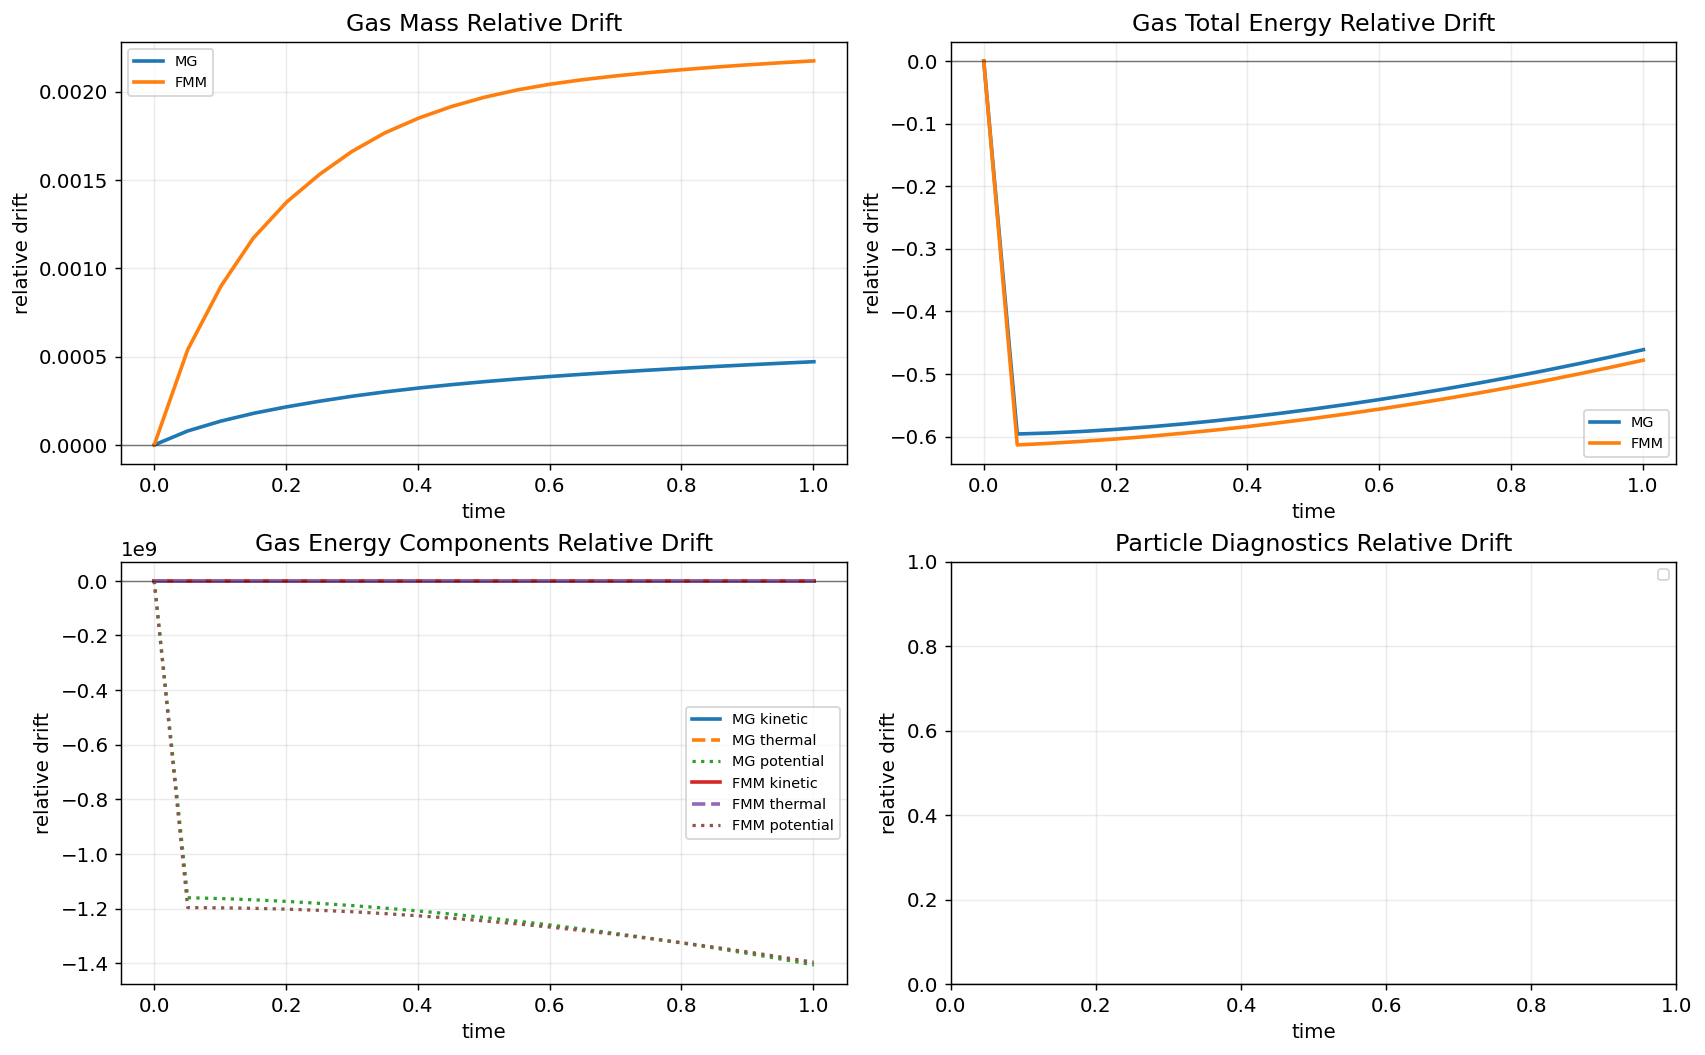

In [15]:
# -----------------------------
# Plot global conservation metrics
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

for label, df in diagnostics.items():
    axes[0, 0].plot(df["time"], df["gas_mass_rel_drift"], lw=2, label=label)
    axes[0, 1].plot(df["time"], df["gas_total_rel_drift"], lw=2, label=label)
    axes[1, 0].plot(df["time"], df["gas_kinetic_rel_drift"], lw=2, label=f"{label} kinetic")
    axes[1, 0].plot(df["time"], df["gas_thermal_rel_drift"], lw=2, ls="--", label=f"{label} thermal")
    axes[1, 0].plot(df["time"], df["gas_potential_rel_drift"], lw=1.8, ls=":", label=f"{label} potential")

    if "part_mass_rel_drift" in df and df["part_mass_rel_drift"].notna().any():
        axes[1, 1].plot(df["time"], df["part_mass_rel_drift"], lw=2, label=f"{label} particle mass")
    if "part_kinetic_rel_drift" in df and df["part_kinetic_rel_drift"].notna().any():
        axes[1, 1].plot(df["time"], df["part_kinetic_rel_drift"], lw=2, ls="--", label=f"{label} particle kinetic")

axes[0, 0].set_title("Gas Mass Relative Drift")
axes[0, 1].set_title("Gas Total Energy Relative Drift")
axes[1, 0].set_title("Gas Energy Components Relative Drift")
axes[1, 1].set_title("Particle Diagnostics Relative Drift")

for ax in axes.ravel():
    ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
    ax.set_xlabel("time")
    ax.set_ylabel("relative drift")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.show()

In [16]:
# -----------------------------
# Match snapshots by time (run A vs run B)
# -----------------------------
labels = list(RUNS.keys())
if len(labels) >= 2:
    run_a, run_b = labels[0], labels[1]
    pair = match_by_time(diagnostics[run_a], diagnostics[run_b], tol=TIME_MATCH_TOLERANCE)
    print(f"Matched pairs between {run_a} and {run_b}: {len(pair)}")
    display(pair.head())
else:
    pair = pd.DataFrame()
    print("Need at least two runs for cross-run matching.")

Matched pairs between MG and FMM: 21


,nout_a,time_a,nout_b,time_b,dt
0,1,0.000000,1,0.000000,0.000000
1,2,0.050791,2,0.050827,0.000036
2,3,0.101367,3,0.101528,0.000162
3,4,0.151698,4,0.150232,-0.001466
4,5,0.200674,5,0.201299,0.000624


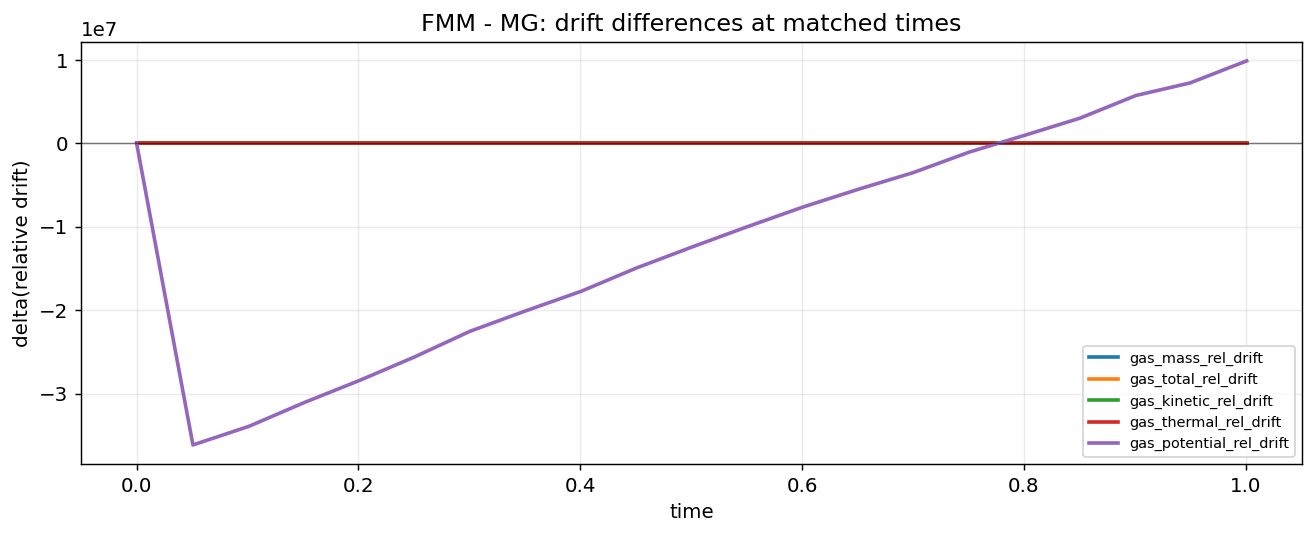

In [17]:
# -----------------------------
# Compare relative drifts directly between matched snapshots
# -----------------------------
if len(pair) > 0:
    run_a, run_b = list(RUNS.keys())[:2]
    A = diagnostics[run_a].set_index("nout")
    B = diagnostics[run_b].set_index("nout")

    cmp = pair.copy()
    for col in ["gas_mass_rel_drift", "gas_total_rel_drift", "gas_kinetic_rel_drift", "gas_thermal_rel_drift", "gas_potential_rel_drift"]:
        if col in A.columns and col in B.columns:
            cmp[f"{col}_delta"] = B.loc[cmp["nout_b"], col].to_numpy() - A.loc[cmp["nout_a"], col].to_numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    for col in cmp.columns:
        if col.endswith("_delta"):
            ax.plot(cmp["time_a"], cmp[col], lw=2, label=col.replace("_delta", ""))
    ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
    ax.set_title(f"{run_b} - {run_a}: drift differences at matched times")
    ax.set_xlabel("time")
    ax.set_ylabel("delta(relative drift)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    plt.show()
else:
    print("No matched pair table available.")

Using snapshot pair: MG nout=21, FMM nout=21, dt=-3.265e-04
ncpu=1 ndim=3 nlevelmax=13
Time= 1.000939004852
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1602672 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 1.00061247944197
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1601923 leaf cells
Extracting leaf cells...
[MG nout=21] x raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000; y raw[304.688,898.828] -> aligned[4.688,598.828] shift=-300.000; z raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000
[FMM nout=21] x raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000; y raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000; z raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000


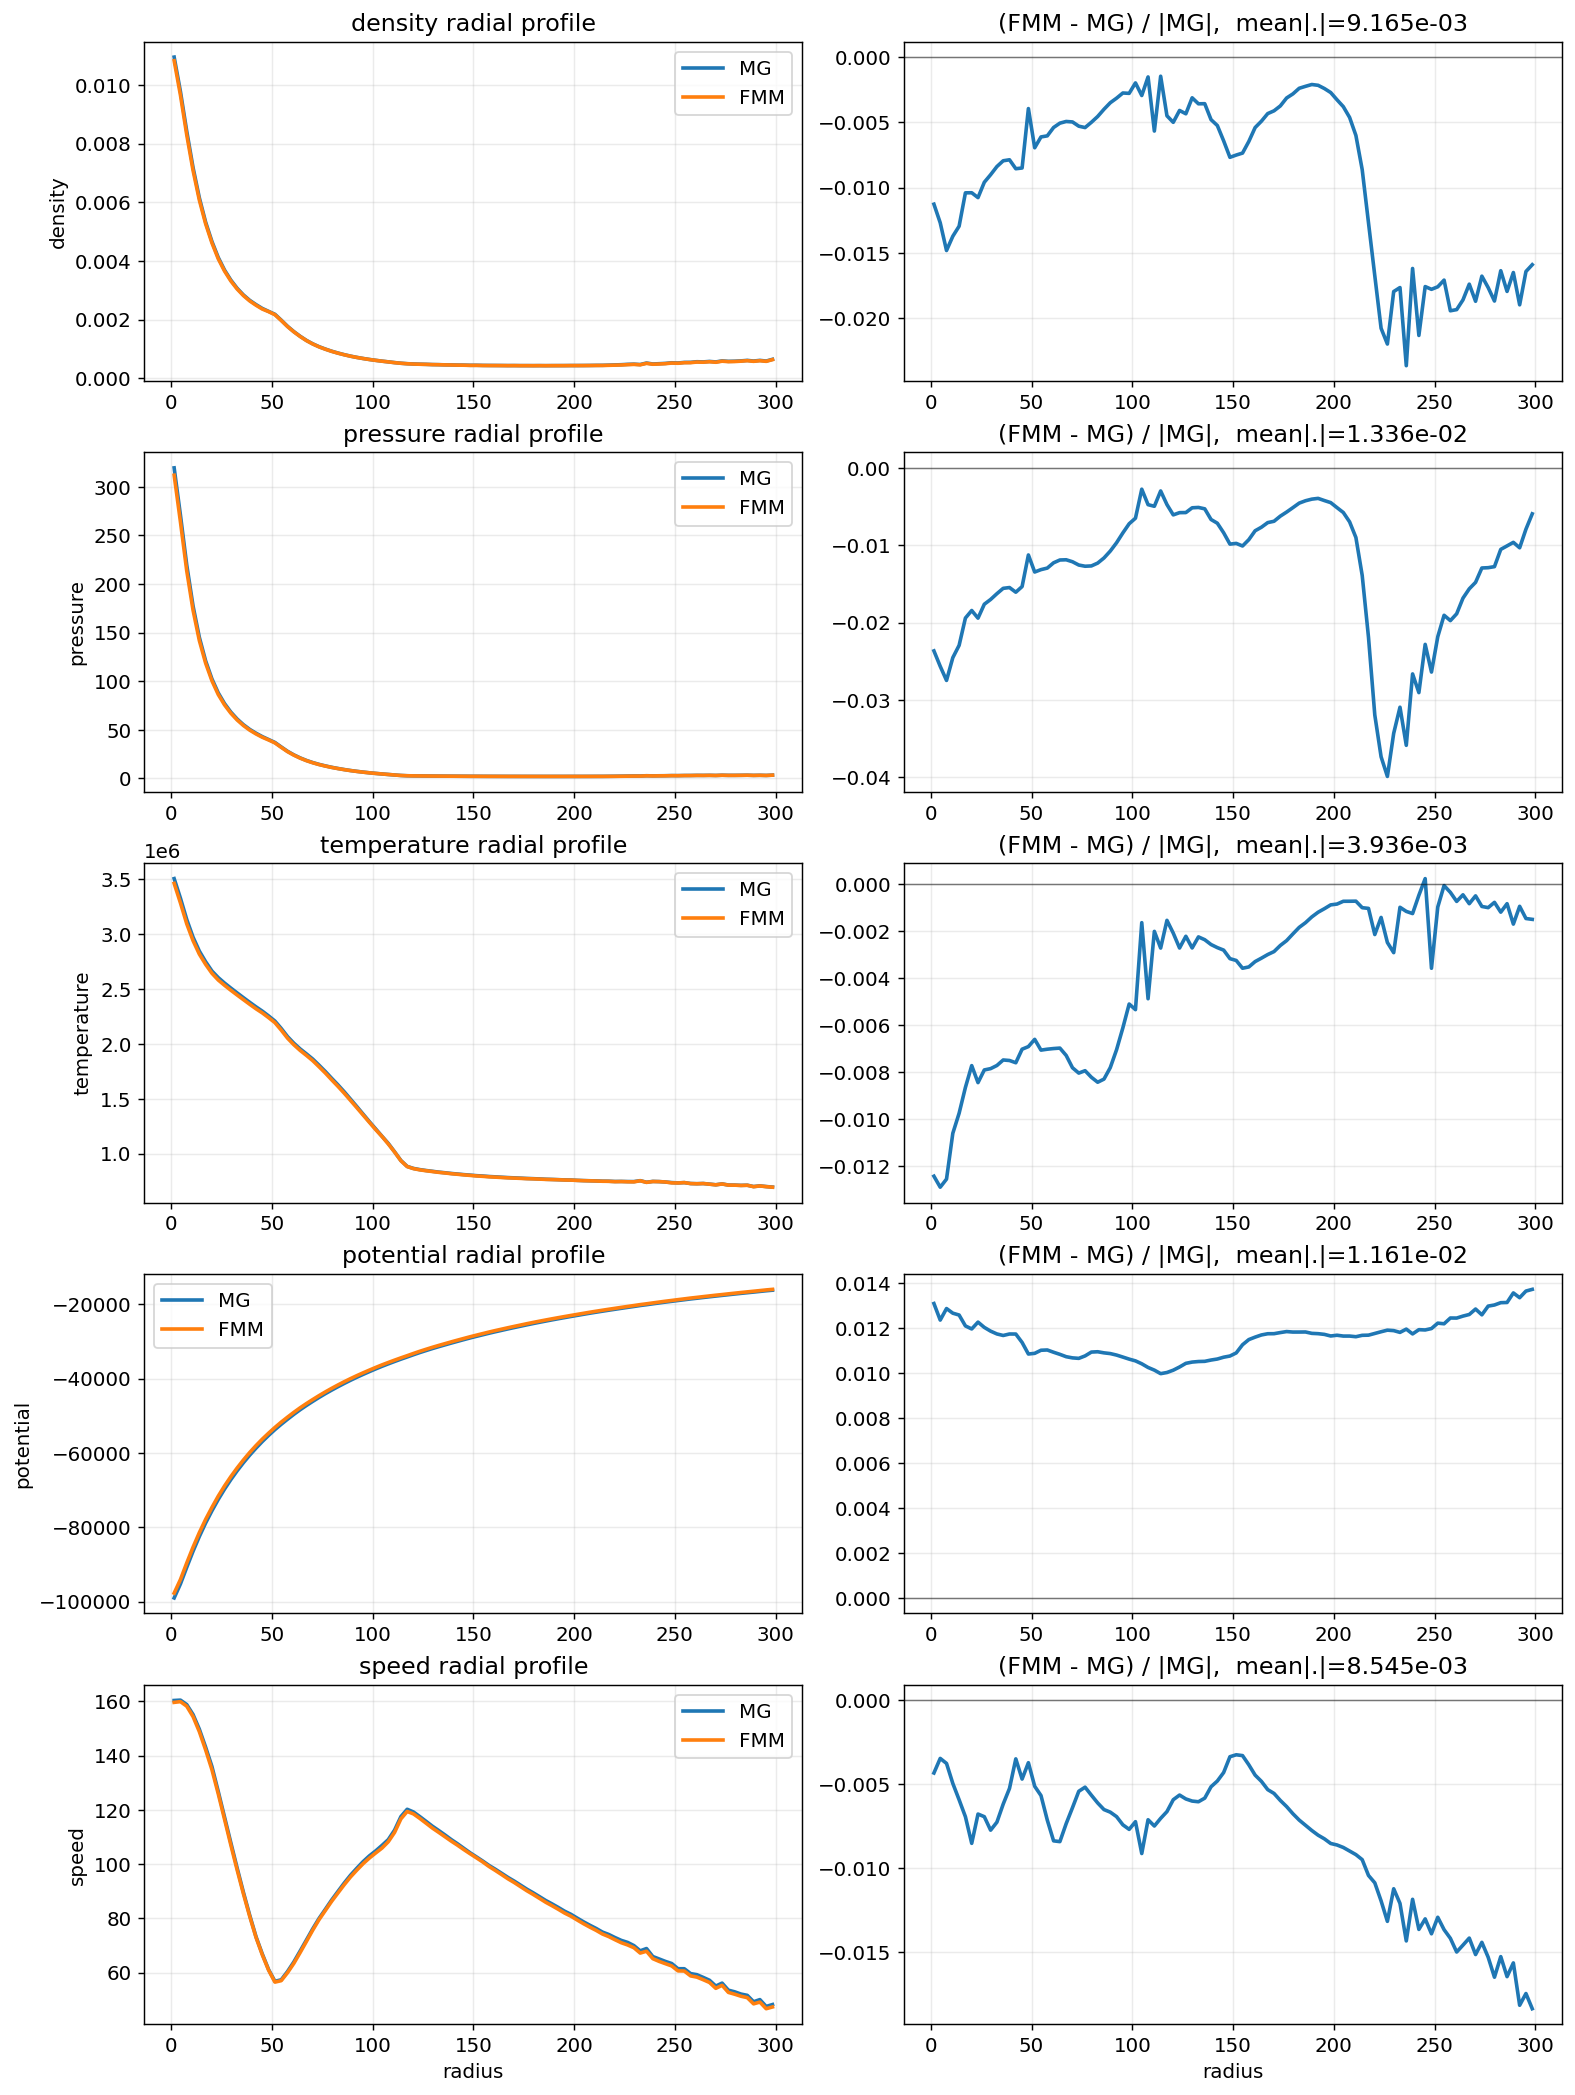

In [18]:
# -----------------------------
# Resolution-matched radial profiles at one matched snapshot pair
# -----------------------------
if len(pair) > 0:
    run_a, run_b = list(RUNS.keys())[:2]
    row = pick_pair_row(pair, PROFILE_SNAPSHOT)
    nout_a, nout_b = int(row["nout_a"]), int(row["nout_b"])
    print(f"Using snapshot pair: {run_a} nout={nout_a}, {run_b} nout={nout_b}, dt={row['dt']:.3e}")

    info_a = ram.rd_info(nout_a, path=RUNS[run_a])
    info_b = ram.rd_info(nout_b, path=RUNS[run_b])

    c_a, mode_a = read_cells(RUNS[run_a], nout_a)
    c_b, mode_b = read_cells(RUNS[run_b], nout_b)

    x_a, sh_a, center_a, boxlen_phys_a = get_aligned_cell_positions(c_a, info_a, CENTER)
    x_b, sh_b, center_b, boxlen_phys_b = get_aligned_cell_positions(c_b, info_b, CENTER)

    if PRINT_ALIGNMENT_DEBUG:
        print(format_alignment(f"{run_a} nout={nout_a}", c_a.x, x_a, sh_a))
        print(format_alignment(f"{run_b} nout={nout_b}", c_b.x, x_b, sh_b))

    f_a = extract_fields(c_a, info_a, parse_header_vars(Path(RUNS[run_a]) / f"output_{nout_a:05d}", "hydro"), mode_a)
    f_b = extract_fields(c_b, info_b, parse_header_vars(Path(RUNS[run_b]) / f"output_{nout_b:05d}", "hydro"), mode_b)

    if RADIUS is not None:
        rr_a = np.sqrt(np.sum((x_a.T - center_a[: c_a.ndim]) ** 2, axis=1))
        rr_b = np.sqrt(np.sum((x_b.T - center_b[: c_b.ndim]) ** 2, axis=1))
        f_a, _ = apply_radial_mask(f_a, rr_a, RADIUS)
        f_b, _ = apply_radial_mask(f_b, rr_b, RADIUS)
        x_a = x_a[:, rr_a <= float(RADIUS)]
        x_b = x_b[:, rr_b <= float(RADIUS)]

    rmax_auto = min(boxlen_phys_a, boxlen_phys_b) * 0.5
    rmax = RADIAL_RMAX if RADIAL_RMAX is not None else rmax_auto
    r_edges = np.linspace(0.0, rmax, N_RADIAL_BINS + 1)
    r_mid = 0.5 * (r_edges[:-1] + r_edges[1:])

    rows = []
    for field in PROFILE_FIELDS:
        va = f_a.get(field, None)
        vb = f_b.get(field, None)
        if va is None or vb is None:
            continue

        pa = radial_profile(x_a, va, center_a, r_edges, f_a["vol"])
        pb = radial_profile(x_b, vb, center_b, r_edges, f_b["vol"])
        rel_err = relative_profile_error(pa, pb)
        rows.append((field, pa, pb, rel_err))

    if len(rows) == 0:
        print("No common profile fields available for this pair.")
    else:
        nplot = len(rows)
        fig, axes = plt.subplots(nplot, 2, figsize=(12, 3.2 * nplot), constrained_layout=True)
        if nplot == 1:
            axes = np.array([axes])

        for i, (field, pa, pb, rel_err) in enumerate(rows):
            ax0, ax1 = axes[i]
            ax0.plot(r_mid, pa, lw=2, label=run_a)
            ax0.plot(r_mid, pb, lw=2, label=run_b)
            ax0.set_ylabel(field)
            ax0.set_title(f"{field} radial profile")
            ax0.grid(alpha=0.25)
            ax0.legend()

            denom = np.where(np.isfinite(pa), np.abs(pa), np.nan)
            drel = (pb - pa) / np.maximum(denom, 1e-30)
            ax1.plot(r_mid, drel, lw=2)
            ax1.axhline(0.0, color="k", lw=0.8, alpha=0.5)
            ax1.set_title(f"({run_b} - {run_a}) / |{run_a}|,  mean|.|={rel_err:.3e}")
            ax1.grid(alpha=0.25)

        axes[-1, 0].set_xlabel("radius")
        axes[-1, 1].set_xlabel("radius")
        plt.show()
else:
    print("No matched snapshot pair; skip profile comparison.")


In [19]:
# -----------------------------
# Optional: profile mismatch metric over time
# -----------------------------
if COMPUTE_PROFILE_MISMATCH_OVER_TIME and len(pair) > 0:
    run_a, run_b = list(RUNS.keys())[:2]

    records = []
    for _, rw in tqdm(pair.iterrows(), total=len(pair), desc="profile mismatch over time"):
        na, nb = int(rw["nout_a"]), int(rw["nout_b"])

        ia = ram.rd_info(na, path=RUNS[run_a])
        ib = ram.rd_info(nb, path=RUNS[run_b])
        ca, ma = read_cells(RUNS[run_a], na)
        cb, mb = read_cells(RUNS[run_b], nb)

        xa, _, center_a, boxlen_phys_a = get_aligned_cell_positions(ca, ia, CENTER)
        xb, _, center_b, boxlen_phys_b = get_aligned_cell_positions(cb, ib, CENTER)

        fa = extract_fields(ca, ia, parse_header_vars(Path(RUNS[run_a]) / f"output_{na:05d}", "hydro"), ma)
        fb = extract_fields(cb, ib, parse_header_vars(Path(RUNS[run_b]) / f"output_{nb:05d}", "hydro"), mb)

        if RADIUS is not None:
            rra = np.sqrt(np.sum((xa.T - center_a[: ca.ndim]) ** 2, axis=1))
            rrb = np.sqrt(np.sum((xb.T - center_b[: cb.ndim]) ** 2, axis=1))
            fa, ma_a = apply_radial_mask(fa, rra, RADIUS)
            fb, ma_b = apply_radial_mask(fb, rrb, RADIUS)
            xa = xa[:, ma_a]
            xb = xb[:, ma_b]

        va = fa.get(PROFILE_MISMATCH_FIELD, None)
        vb = fb.get(PROFILE_MISMATCH_FIELD, None)
        if va is None or vb is None:
            err = np.nan
        else:
            rmax = RADIAL_RMAX if RADIAL_RMAX is not None else min(boxlen_phys_a, boxlen_phys_b) * 0.5
            r_edges = np.linspace(0.0, rmax, N_RADIAL_BINS + 1)
            pa = radial_profile(xa, va, center_a, r_edges, fa["vol"])
            pb = radial_profile(xb, vb, center_b, r_edges, fb["vol"])
            err = relative_profile_error(pa, pb)

        records.append({"time_a": rw["time_a"], "nout_a": na, "nout_b": nb, "profile_rel_l1": err})

    mismatch_df = pd.DataFrame(records)
    display(mismatch_df.head())

    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    ax.plot(mismatch_df["time_a"], mismatch_df["profile_rel_l1"], lw=2)
    ax.set_title(f"Resolution-matched profile mismatch over time ({PROFILE_MISMATCH_FIELD})")
    ax.set_xlabel("time")
    ax.set_ylabel("mean relative L1 mismatch")
    ax.grid(alpha=0.25)
    plt.show()
else:
    print("Skipped profile mismatch over time (set COMPUTE_PROFILE_MISMATCH_OVER_TIME=True to run).")


Skipped profile mismatch over time (set COMPUTE_PROFILE_MISMATCH_OVER_TIME=True to run).


ncpu=1 ndim=3 nlevelmax=13
Time= 1.000939004852
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1602672 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=13
Time= 1.00061247944197
Reading grid data...
Found nvar=7
Reading hydro data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1601923 leaf cells
Extracting leaf cells...
[MG nout=21] x raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000; y raw[304.688,898.828] -> aligned[4.688,598.828] shift=-300.000; z raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000
[FMM nout=21] x raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000; y raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000; z raw[304.688,897.656] -> aligned[4.688,597.656] shift=-300.000


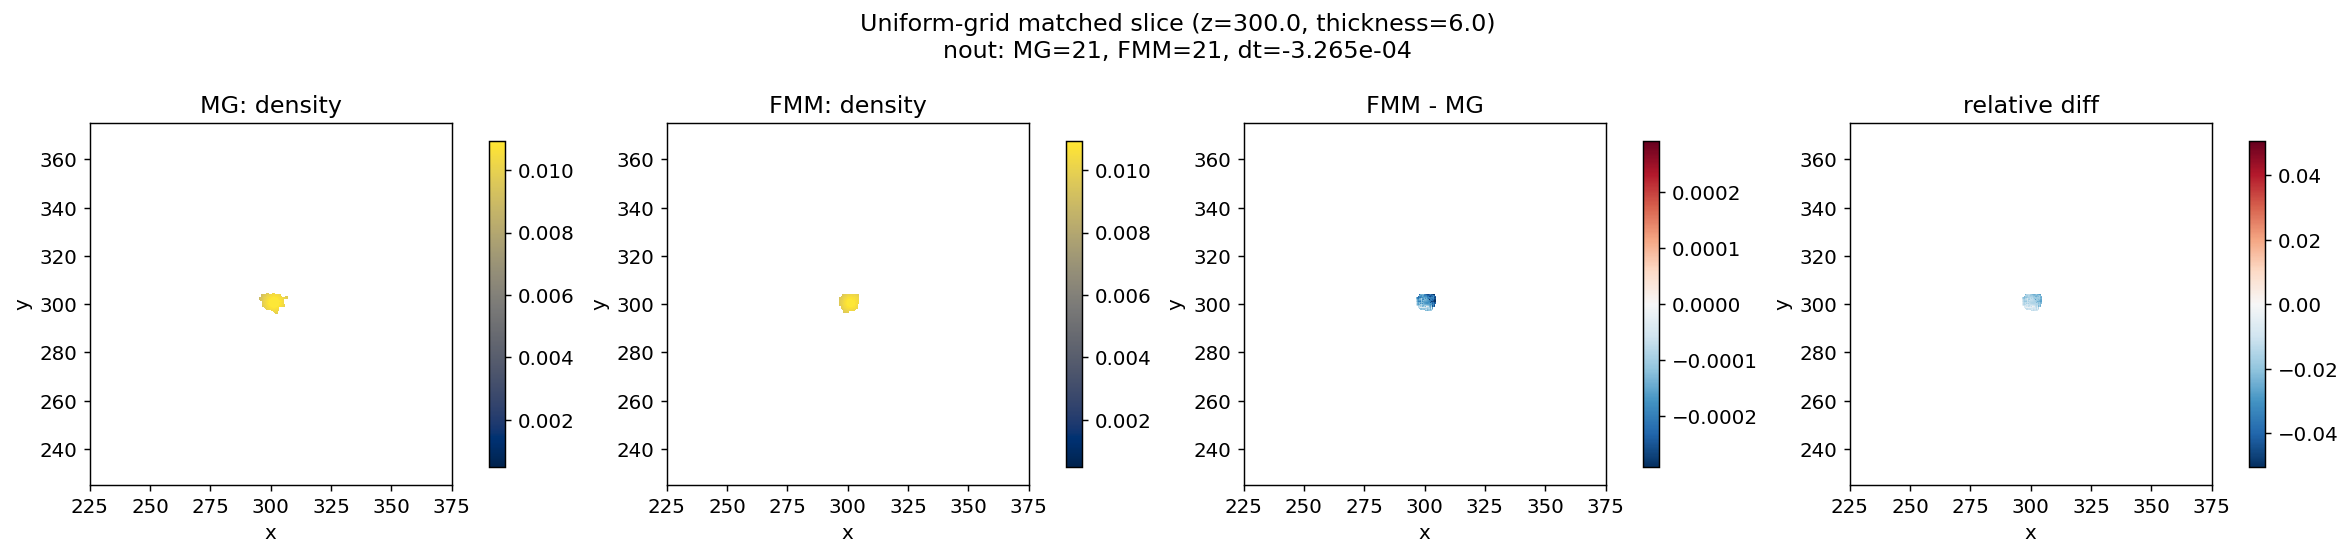

In [20]:
# -----------------------------
# Resolution-matched 2D slice comparison on a shared uniform grid
# -----------------------------
if len(pair) > 0:
    run_a, run_b = list(RUNS.keys())[:2]
    row = pick_pair_row(pair, PROFILE_SNAPSHOT)
    nout_a, nout_b = int(row["nout_a"]), int(row["nout_b"])

    ia = ram.rd_info(nout_a, path=RUNS[run_a])
    ib = ram.rd_info(nout_b, path=RUNS[run_b])
    ca, ma = read_cells(RUNS[run_a], nout_a)
    cb, mb = read_cells(RUNS[run_b], nout_b)

    xa, sha, center_a, _ = get_aligned_cell_positions(ca, ia, CENTER)
    xb, shb, center_b, _ = get_aligned_cell_positions(cb, ib, CENTER)

    if PRINT_ALIGNMENT_DEBUG:
        print(format_alignment(f"{run_a} nout={nout_a}", ca.x, xa, sha))
        print(format_alignment(f"{run_b} nout={nout_b}", cb.x, xb, shb))

    fa = extract_fields(ca, ia, parse_header_vars(Path(RUNS[run_a]) / f"output_{nout_a:05d}", "hydro"), ma)
    fb = extract_fields(cb, ib, parse_header_vars(Path(RUNS[run_b]) / f"output_{nout_b:05d}", "hydro"), mb)

    field = MAP_FIELD
    if fa.get(field, None) is None or fb.get(field, None) is None:
        print(f"Field '{field}' unavailable in one run; falling back to potential")
        field = "potential"

    va = fa[field]
    vb = fb[field]

    img_a, box, *_ = uniform_slice_binned(xa, ca.dx, ca.ndim, va, z0=SLICE_Z, thickness=SLICE_THICKNESS, nxy=SLICE_NXY, box=SLICE_BOX)
    img_b, _, *_ = uniform_slice_binned(xb, cb.dx, cb.ndim, vb, z0=SLICE_Z, thickness=SLICE_THICKNESS, nxy=SLICE_NXY, box=box)

    diff = img_b - img_a
    rel = diff / np.maximum(np.abs(img_a), 1e-30)

    allv = np.concatenate([img_a[np.isfinite(img_a)], img_b[np.isfinite(img_b)]])
    vmin, vmax = np.nanpercentile(allv, [1, 99]) if allv.size else (0, 1)
    dlim = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 99) if np.isfinite(diff).any() else 1.0
    rlim = np.nanpercentile(np.abs(rel[np.isfinite(rel)]), 99) if np.isfinite(rel).any() else 1.0

    extent = [box[0], box[1], box[2], box[3]]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), constrained_layout=True)
    im0 = axes[0].imshow(img_a, origin="lower", extent=extent, vmin=vmin, vmax=vmax, cmap="cividis")
    axes[0].set_title(f"{run_a}: {field}")
    plt.colorbar(im0, ax=axes[0], fraction=0.045)

    im1 = axes[1].imshow(img_b, origin="lower", extent=extent, vmin=vmin, vmax=vmax, cmap="cividis")
    axes[1].set_title(f"{run_b}: {field}")
    plt.colorbar(im1, ax=axes[1], fraction=0.045)

    im2 = axes[2].imshow(diff, origin="lower", extent=extent, cmap="RdBu_r", vmin=-dlim, vmax=dlim)
    axes[2].set_title(f"{run_b} - {run_a}")
    plt.colorbar(im2, ax=axes[2], fraction=0.045)

    im3 = axes[3].imshow(rel, origin="lower", extent=extent, cmap="RdBu_r", vmin=-rlim, vmax=rlim)
    axes[3].set_title(f"relative diff")
    plt.colorbar(im3, ax=axes[3], fraction=0.045)

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(
        f"Uniform-grid matched slice (z={SLICE_Z}, thickness={SLICE_THICKNESS})\n"
        f"nout: {run_a}={nout_a}, {run_b}={nout_b}, dt={row['dt']:.3e}",
        y=1.04,
    )
    plt.show()
else:
    print("No matched pair; skip uniform-grid map comparison.")


In [21]:
# -----------------------------
# Save diagnostics tables
# -----------------------------
if SAVE_RESULTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    for label, df in diagnostics.items():
        df.to_csv(RESULTS_DIR / f"{label.lower()}_diagnostics.csv", index=False)

    if 'pair' in globals() and len(pair) > 0:
        pair.to_csv(RESULTS_DIR / "matched_pairs.csv", index=False)

    print(f"Saved tables to: {RESULTS_DIR.resolve()}")
else:
    print("SAVE_RESULTS=False; no files written.")

Saved tables to: /home/jl4415/mini-ramses/analyze/isolated_halo_stability_results


## Notes / interpretation

- `gas_total` is computed as `kinetic + thermal + 0.5*rho*phi` volume-integrated over leaf cells.
- If `hydro.*` is missing, gas quantities are `NaN` and the notebook falls back to potential/particle diagnostics when possible.
- Cross-run comparisons use nearest-time matching (`merge_asof`) because output numbering can differ.
- Radial profiles and uniform-grid slices are AMR-agnostic ways to compare solutions even when refinement patterns differ.
- For strict energy accounting with particles + gas, particle potential terms would require additional interpolation/integration not included here.